In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm
import math
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    cont-src-1  cont-src-2  radiation-reading  source
2     0.731024    0.733000       7.710875e-16    file
7     0.683418    0.861057       2.535001e-40    file
1     0.574329    0.879898       1.033078e-46    file
9     0.883890    0.582254       6.229856e-48    file
0     0.319404    0.762959       1.322677e-79    file
8     0.082507    0.403488       3.606771e-81    file
3     0.840353    0.264732      3.341771e-124    file
12    0.579291    1.059596      4.507438e-133  week-3
11    0.404040    0.959596     -9.343448e-112  week-2
6     0.312691    0.078723      -2.089093e-91    file
13    0.436769    0.825163      -1.519972e-55  week-4
5     0.410437    0.147554      -2.159249e-54    file
10    0.848485    0.777778      -1.248783e-49  week-1
4     0.650114    0.681526      -3.606063e-03    file


/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_44189/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


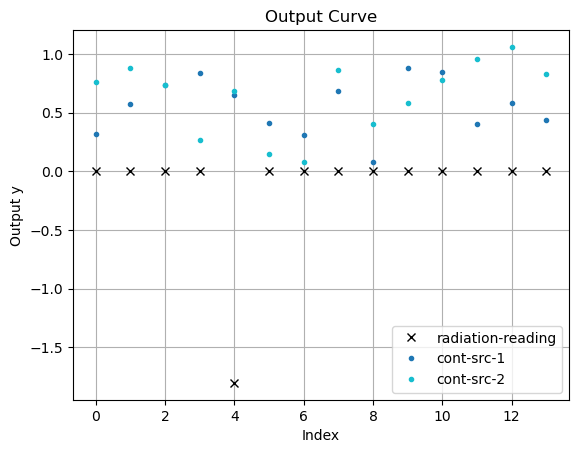

In [11]:
#Process data
%run data_handler.ipynb

In [12]:
X = inputs
y = outputs

In [13]:
%run ../common_functions.ipynb
# Initialize result collection
query_results = []


In [ ]:
def sweep_hyperparameters_NNtrain(X, y,
                                  xi_values=[0.01, 0.1, 0.3],
                                  kappa_values=[1.0, 2.0, 5.0],
                                  grid_sizes=[400],
                                  methods=['PI', 'EI', 'UCB'],
                                  apply_scaling=False,
                                  filter_mode='gp'):
    """
    Sweep hyperparameters for SurrogateTrainer-based query selection.
    Equivalent to sweep_hyperparameters_fixedNN but uses a trained surrogate.
    """
    # Clear global query_results at the start
    global query_results
    query_results = []

    for method in methods:
        if method in ['PI', 'EI']:
            for xi in xi_values:
                for grid_size in grid_sizes:
                    next_query, acq_map, _ = select_next_query_multi_NNtrain(
                        X, y, method=method, xi=xi, grid_size=grid_size,
                        apply_scaling=apply_scaling, filter_mode=filter_mode
                    )
                    if next_query is None or acq_map is None:
                        print(f"⚠️ Skipping config: method={method}, xi={xi}, grid_size={grid_size}")
                        continue
                    score = np.max(acq_map)
                    log_query_candidate(method, xi, next_query, score)

        elif method == 'UCB':
            for kappa in kappa_values:
                for grid_size in grid_sizes:
                    next_query, acq_map, _ = select_next_query_multi_NNtrain(
                        X, y, method=method, kappa=kappa, grid_size=grid_size,
                        apply_scaling=apply_scaling, filter_mode=filter_mode
                    )
                    if next_query is None or acq_map is None:
                        print(f"⚠️ Skipping config: method={method}, kappa={kappa}, grid_size={grid_size}")
                        continue
                    score = np.max(acq_map)
                    log_query_candidate(method, kappa, next_query, score)

    if not query_results:
        raise RuntimeError("No valid configurations found during sweep.")

    best = find_best_candidate(query_results)
    return best, query_results

In [15]:
best, query_results = sweep_hyperparameters_NNtrain(X, y, filter_mode='gp')

Input space dimension: 2
Skipping scaling.
Computing bounds with margin 0.1.
Bounds per feature: [(-0.017492748179194134, 0.983889828818117), (-0.02127722205028118, 1.159596)]
Creating 50^(2) grid.
Grid shape: (2500, 2)
Points before filtering: 2500
Filtering grid using mode: gp
Grid shape before filtering: (2500, 2)
Filtered 0 candidates near decision boundary (|margin| < 0.2)
Excluded 2500 candidates from consideration
Final grid shape: (0, 2)
Filtered grid shape: (0, 2)
Final grid shape: (0, 2)
⚠️ Warning: SVM filter removed all grid points. Skipping this configuration.
⚠️ Skipping config: method=PI, xi=0.01, grid_size=50
Input space dimension: 2
Skipping scaling.
Computing bounds with margin 0.1.
Bounds per feature: [(-0.017492748179194134, 0.983889828818117), (-0.02127722205028118, 1.159596)]
Creating 75^(2) grid.
Grid shape: (5625, 2)
Points before filtering: 5625
Filtering grid using mode: gp
Grid shape before filtering: (5625, 2)
Filtered 136 candidates near decision boundary (

/Users/ajay.amrite/Documents/AI Course/Anaconda Files/Module - 12/Black-Box functions/utils/SurrogateNN.py:60: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  print(f"  {name}: mean={param.data.mean():.4f}, std={param.data.std():.4f}")


Filtered 310 candidates near decision boundary (|margin| < 0.2)
Excluded 9690 candidates from consideration
Final grid shape: (310, 2)
Filtered grid shape: (310, 2)
Final grid shape: (310, 2)
Epoch 1/500, Loss: 1.001511
  model.0.weight: mean=-0.0631, std=0.4102
  model.0.bias: mean=0.0226, std=0.3751
  model.2.weight: mean=-0.0009, std=0.0725
  model.2.bias: mean=0.0114, std=0.0662
  model.4.weight: mean=0.0073, std=0.0733
  model.4.bias: mean=-0.0722, std=nan
Epoch 50/500, Loss: 0.614809
  model.0.weight: mean=-0.0621, std=0.4238
  model.0.bias: mean=0.0340, std=0.3732
  model.2.weight: mean=0.0000, std=0.0789
  model.2.bias: mean=0.0184, std=0.0726
  model.4.weight: mean=0.0143, std=0.1014
  model.4.bias: mean=-0.1171, std=nan
Epoch 100/500, Loss: 0.221680
  model.0.weight: mean=-0.0693, std=0.4488
  model.0.bias: mean=0.0591, std=0.3721
  model.2.weight: mean=0.0019, std=0.0939
  model.2.bias: mean=0.0290, std=0.0840
  model.4.weight: mean=0.0173, std=0.1434
  model.4.bias: mean=-0

/Users/ajay.amrite/Documents/AI Course/Anaconda Files/Module - 12/Black-Box functions/utils/SurrogateNN.py:60: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  print(f"  {name}: mean={param.data.mean():.4f}, std={param.data.std():.4f}")


Filtered 0 candidates near decision boundary (|margin| < 0.2)
Excluded 2500 candidates from consideration
Final grid shape: (0, 2)
Filtered grid shape: (0, 2)
Final grid shape: (0, 2)
⚠️ Warning: SVM filter removed all grid points. Skipping this configuration.
⚠️ Skipping config: method=PI, xi=0.1, grid_size=50
Input space dimension: 2
Skipping scaling.
Computing bounds with margin 0.1.
Bounds per feature: [(-0.017492748179194134, 0.983889828818117), (-0.02127722205028118, 1.159596)]
Creating 75^(2) grid.
Grid shape: (5625, 2)
Points before filtering: 5625
Filtering grid using mode: gp
Grid shape before filtering: (5625, 2)
Filtered 136 candidates near decision boundary (|margin| < 0.2)
Excluded 5489 candidates from consideration
Final grid shape: (136, 2)
Filtered grid shape: (136, 2)
Final grid shape: (136, 2)
Epoch 1/500, Loss: 0.995756
  model.0.weight: mean=0.0049, std=0.4023
  model.0.bias: mean=-0.0138, std=0.3821
  model.2.weight: mean=-0.0014, std=0.0711
  model.2.bias: mean=0

...

/Users/ajay.amrite/Documents/AI Course/Anaconda Files/Module - 12/Black-Box functions/utils/SurrogateNN.py:60: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  print(f"  {name}: mean={param.data.mean():.4f}, std={param.data.std():.4f}")


Filtered 0 candidates near decision boundary (|margin| < 0.2)
Excluded 2500 candidates from consideration
Final grid shape: (0, 2)
Filtered grid shape: (0, 2)
Final grid shape: (0, 2)
⚠️ Warning: SVM filter removed all grid points. Skipping this configuration.
⚠️ Skipping config: method=UCB, kappa=5.0, grid_size=50
Input space dimension: 2
Skipping scaling.
Computing bounds with margin 0.1.
Bounds per feature: [(-0.017492748179194134, 0.983889828818117), (-0.02127722205028118, 1.159596)]
Creating 75^(2) grid.
Grid shape: (5625, 2)
Points before filtering: 5625
Filtering grid using mode: gp
Grid shape before filtering: (5625, 2)
Filtered 136 candidates near decision boundary (|margin| < 0.2)
Excluded 5489 candidates from consideration
Final grid shape: (136, 2)
Filtered grid shape: (136, 2)
Final grid shape: (136, 2)
Epoch 1/500, Loss: 0.973908
  model.0.weight: mean=0.0543, std=0.3931
  model.0.bias: mean=-0.0547, std=0.3976
  model.2.weight: mean=0.0002, std=0.0723
  model.2.bias: mea

/Users/ajay.amrite/Documents/AI Course/Anaconda Files/Module - 12/Black-Box functions/utils/SurrogateNN.py:60: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  print(f"  {name}: mean={param.data.mean():.4f}, std={param.data.std():.4f}")


Filtered 310 candidates near decision boundary (|margin| < 0.2)
Excluded 9690 candidates from consideration
Final grid shape: (310, 2)
Filtered grid shape: (310, 2)
Final grid shape: (310, 2)
Epoch 1/500, Loss: 0.974290
  model.0.weight: mean=0.0334, std=0.3987
  model.0.bias: mean=-0.0269, std=0.4101
  model.2.weight: mean=0.0002, std=0.0724
  model.2.bias: mean=-0.0106, std=0.0710
  model.4.weight: mean=-0.0021, std=0.0730
  model.4.bias: mean=0.0440, std=nan
Epoch 50/500, Loss: 0.521158
  model.0.weight: mean=0.0376, std=0.4138
  model.0.bias: mean=-0.0105, std=0.4125
  model.2.weight: mean=0.0011, std=0.0805
  model.2.bias: mean=-0.0022, std=0.0818
  model.4.weight: mean=0.0020, std=0.1055
  model.4.bias: mean=-0.0023, std=nan
Epoch 100/500, Loss: 0.227788
  model.0.weight: mean=0.0377, std=0.4357
  model.0.bias: mean=0.0036, std=0.4115
  model.2.weight: mean=0.0010, std=0.0935
  model.2.bias: mean=0.0039, std=0.0890
  model.4.weight: mean=-0.0007, std=0.1400
  model.4.bias: mean=-

/Users/ajay.amrite/Documents/AI Course/Anaconda Files/Module - 12/Black-Box functions/utils/SurrogateNN.py:60: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  print(f"  {name}: mean={param.data.mean():.4f}, std={param.data.std():.4f}")


In [16]:
print("Best Hyperparameter Configuration:")
print(best)

Best Hyperparameter Configuration:
{'method': 'UCB', 'xi': None, 'kappa': 5.0, 'x': array([0.86251012, 0.12185893]), 'score': 0.7237047066013631, 'dim': 2}


In [17]:
#add points to dataframe
#print(df)
add_points_to_df(df_sorted, query_results)
pd.set_option('display.max_rows', None)
print(df_sorted)

    cont-src-1  cont-src-2  radiation-reading  source
2     0.731024    0.733000       7.710875e-16    file
7     0.683418    0.861057       2.535001e-40    file
1     0.574329    0.879898       1.033078e-46    file
9     0.883890    0.582254       6.229856e-48    file
0     0.319404    0.762959       1.322677e-79    file
8     0.082507    0.403488       3.606771e-81    file
3     0.840353    0.264732      3.341771e-124    file
12    0.579291    1.059596      4.507438e-133  week-3
11    0.404040    0.959596     -9.343448e-112  week-2
6     0.312691    0.078723      -2.089093e-91    file
13    0.436769    0.825163      -1.519972e-55  week-4
5     0.410437    0.147554      -2.159249e-54    file
10    0.848485    0.777778      -1.248783e-49  week-1
4     0.650114    0.681526      -3.606063e-03    file
14    0.510263    0.968103                NaN  week-x
15    0.862510    0.121859                NaN  week-x
16    0.510263    0.968103                NaN  week-x
17    0.862510    0.121859  

/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_44189/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


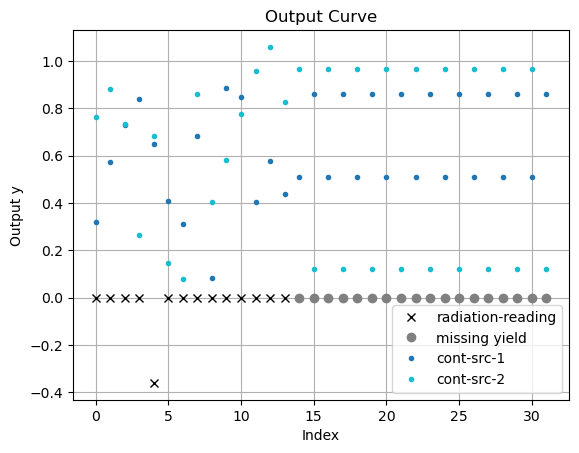

In [18]:
plot_output_points(df_sorted, scale_factor=1.0, yield_scale_factor=100.0, nan_marker='o')